# Step 1: Data & Network Architecture

**Goal of this project:** build a neural network that recognizes handwritten digits (0-9) — using only NumPy, no TensorFlow, no PyTorch, no `scikit-learn` model classes. Every piece of the math (forward pass, backpropagation, gradient descent) gets implemented by hand. The point isn't that this is the best way to build a neural net in practice — libraries exist for good reason — it's that understanding what those libraries actually do underneath is the difference between using a tool and understanding it.

**Dataset:** [MNIST](http://yann.lecun.com/exdb/mnist/) — 70,000 images of handwritten digits (60,000 for training, 10,000 for testing), each a 28x28 pixel grayscale image. One of the most famous datasets in machine learning, public domain.

## What is a neuron?

Strip away the biology metaphor and a single "neuron" in a neural network does something very simple:

1. Take a bunch of input numbers.
2. Multiply each one by its own **weight** (a number the network learns).
3. Add them all up, plus one extra learned number called the **bias**.
4. Pass that sum through an **activation function** — a simple nonlinear function that decides how "active" the neuron is.

That's it: `output = activation(weight_1 * input_1 + weight_2 * input_2 + ... + bias)`. A neural network is just many of these stacked in layers, so simple pieces combine into something that can learn complex patterns — like what makes a "7" look like a "7".

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from mnist_loader import load_mnist

X_train, y_train, X_test, y_test = load_mnist()
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (60000, 784)
y_train: (60000,)
X_test: (10000, 784)
y_test: (10000,)


`X_train` has shape `(60000, 784)`: 60,000 images, each already flattened from a 28x28 grid into a single row of 784 numbers (28 x 28 = 784). Pixel values are scaled to the range [0, 1] instead of the original 0-255 — networks train more reliably on small, consistent input ranges than on raw pixel brightness.

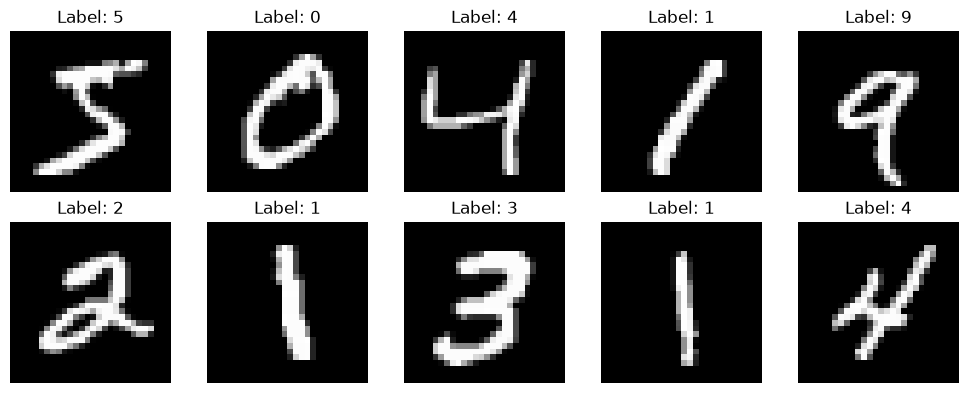

In [2]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap="gray")
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis("off")
plt.tight_layout()
plt.savefig("assets/sample_digits.png", dpi=120)
plt.show()

## Planning the network's architecture

This project builds an **MLP** (Multi-Layer Perceptron) — the simplest kind of neural network, where every neuron in one layer connects to every neuron in the next. Three layers:

| Layer | Size | Why |
|---|---|---|
| Input | 784 | One number per pixel - no choice here, it's fixed by the data |
| Hidden | 128 | A design choice - enough neurons to learn useful patterns, small enough to train fast on a laptop |
| Output | 10 | One per digit class (0-9) - fixed by the problem |

**Why a hidden layer at all?** A network with no hidden layer (input straight to output) can only learn a straight-line decision boundary between classes - it can't tell a curvy "3" from a curvy "8" using pixel brightness alone. The hidden layer lets the network first learn to detect smaller patterns (edges, curves, loops), then combine those into a full digit classification in the output layer.

In [3]:
INPUT_SIZE = 784   # 28 x 28 pixels
HIDDEN_SIZE = 128  # chosen design parameter
OUTPUT_SIZE = 10   # digits 0-9

print(f"Architecture: {INPUT_SIZE} -> {HIDDEN_SIZE} -> {OUTPUT_SIZE}")

Architecture: 784 -> 128 -> 10


## What the weights actually look like

Between the input and hidden layer, every one of the 784 input pixels connects to every one of the 128 hidden neurons - that's `784 x 128 = 100,352` individual weights, plus 128 bias values (one per hidden neuron). Between the hidden and output layer: `128 x 10 = 1,280` weights, plus 10 biases. All of these numbers start out random and get adjusted during training (Step 4) - that adjustment process **is** what "learning" means for a neural network.

In [4]:
n_weights_1 = INPUT_SIZE * HIDDEN_SIZE
n_weights_2 = HIDDEN_SIZE * OUTPUT_SIZE
n_biases = HIDDEN_SIZE + OUTPUT_SIZE
total_params = n_weights_1 + n_weights_2 + n_biases

print(f"Weights (input -> hidden): {n_weights_1:,}")
print(f"Weights (hidden -> output): {n_weights_2:,}")
print(f"Biases: {n_biases}")
print(f"Total learnable parameters: {total_params:,}")

Weights (input -> hidden): 100,352
Weights (hidden -> output): 1,280
Biases: 138
Total learnable parameters: 101,770


~101,000 numbers, all learned from data, to recognize a handwritten digit. That's tiny by modern standards (large language models have billions), but the underlying mechanism - forward pass, loss, backpropagation, gradient descent - is exactly the same idea scaled up.

## What's coming next

- **Step 2:** implement the forward pass - pushing an image through the network to get a prediction (with random, untrained weights first, just to prove the mechanics work).
- **Step 3:** measure how wrong that prediction is (loss), and work out - via backpropagation - how to adjust every single weight to make it less wrong.
- **Step 4:** repeat that adjustment thousands of times (training loop) until the network actually learns.